# Load Balancing Benchmark Notebook

This notebook benchmarks three load balancing algorithms on a synthetic dataset:
- Greedy (LPT)
- Local Search
- Genetic Algorithm

It includes dataset generation (1000 samples), visualization, stratified test subset creation, algorithm comparison (execution time, precision, error rate), interpretation, and a final conclusion.

In [10]:
# If dependencies are missing, uncomment and run the next line:
# %pip install numpy pandas matplotlib

import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

plt.style.use('ggplot')

In [11]:
# 1) Generate a large dataset (~1000 samples)
N_SAMPLES = 1000
N_TASKS = 12
N_SERVERS = 3

rng = np.random.default_rng(SEED)

def generate_instance(local_rng, n_tasks=N_TASKS):
    profile = local_rng.choice(['balanced', 'skewed', 'bursty'], p=[0.45, 0.35, 0.20])

    if profile == 'balanced':
        tasks = local_rng.normal(loc=50, scale=12, size=n_tasks)
    elif profile == 'skewed':
        tasks = local_rng.lognormal(mean=3.6, sigma=0.55, size=n_tasks)
    else:
        base = local_rng.normal(loc=30, scale=8, size=n_tasks)
        spikes = local_rng.binomial(1, 0.18, size=n_tasks) * local_rng.normal(85, 20, size=n_tasks)
        tasks = base + spikes

    tasks = np.clip(np.rint(tasks), 1, 200).astype(int)
    return tasks

dataset = np.array([generate_instance(rng) for _ in range(N_SAMPLES)], dtype=int)

df_instances = pd.DataFrame({
    'sample_id': np.arange(N_SAMPLES),
    'total_load': dataset.sum(axis=1),
    'mean_task': dataset.mean(axis=1),
    'std_task': dataset.std(axis=1),
    'max_task': dataset.max(axis=1),
})

df_instances['cv'] = df_instances['std_task'] / (df_instances['mean_task'] + 1e-9)
df_instances['difficulty_score'] = 0.6 * df_instances['cv'] + 0.4 * (df_instances['max_task'] / (df_instances['mean_task'] + 1e-9))

print(f'Dataset shape: {dataset.shape} (samples x tasks)')
df_instances.head()

Dataset shape: (1000, 12) (samples x tasks)


,sample_id,total_load,mean_task,std_task,max_task,cv,difficulty_score
0,0,450,37.500000,16.260894,61,0.433624,0.910841
1,1,445,37.083333,25.250275,119,0.680906,1.692139
2,2,437,36.416667,19.180973,83,0.526709,1.227696
3,3,463,38.583333,14.671164,59,0.380246,0.839811
4,4,435,36.250000,10.215389,52,0.281804,0.742875


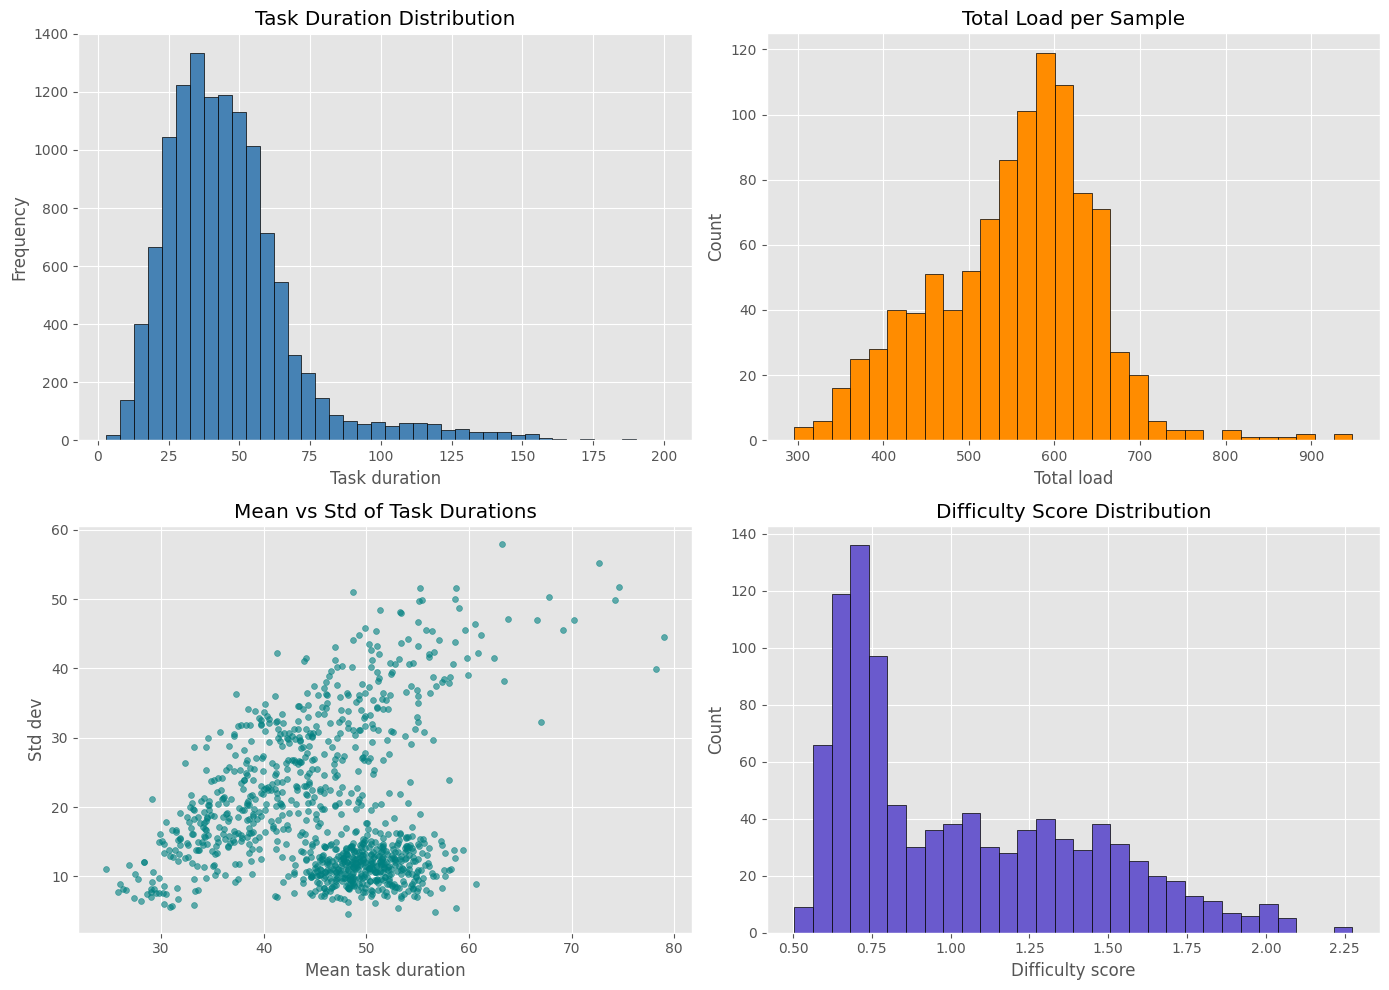

In [12]:
# 2) Visualize generated dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(dataset.flatten(), bins=40, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Task Duration Distribution')
axes[0, 0].set_xlabel('Task duration')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(df_instances['total_load'], bins=30, color='darkorange', edgecolor='black')
axes[0, 1].set_title('Total Load per Sample')
axes[0, 1].set_xlabel('Total load')
axes[0, 1].set_ylabel('Count')

axes[1, 0].scatter(df_instances['mean_task'], df_instances['std_task'], s=18, alpha=0.6, color='teal')
axes[1, 0].set_title('Mean vs Std of Task Durations')
axes[1, 0].set_xlabel('Mean task duration')
axes[1, 0].set_ylabel('Std dev')

axes[1, 1].hist(df_instances['difficulty_score'], bins=30, color='slateblue', edgecolor='black')
axes[1, 1].set_title('Difficulty Score Distribution')
axes[1, 1].set_xlabel('Difficulty score')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [13]:
# 3) Build a good testing subset (stratified by difficulty)
N_TEST = 800

df_instances['difficulty_bin'] = pd.qcut(df_instances['difficulty_score'], q=5, labels=False, duplicates='drop')
bins = sorted(df_instances['difficulty_bin'].dropna().unique())
per_bin = max(1, N_TEST // len(bins))

test_indices = []
for b in bins:
    group_idx = df_instances.index[df_instances['difficulty_bin'] == b].to_numpy()
    take = min(per_bin, len(group_idx))
    chosen = rng.choice(group_idx, size=take, replace=False).tolist()
    test_indices.extend(chosen)

remaining = N_TEST - len(test_indices)
if remaining > 0:
    pool = np.array(sorted(set(df_instances.index) - set(test_indices)))
    extra = rng.choice(pool, size=remaining, replace=False).tolist()
    test_indices.extend(extra)

test_indices = sorted(test_indices)
test_dataset = dataset[test_indices]
df_test = df_instances.loc[test_indices].copy()

print(f'Testing subset size: {len(test_indices)} samples')
print('Difficulty bins in subset:')
print(df_test['difficulty_bin'].value_counts().sort_index())

Testing subset size: 800 samples
Difficulty bins in subset:
difficulty_bin
0    160
1    160
2    160
3    160
4    160
Name: count, dtype: int64


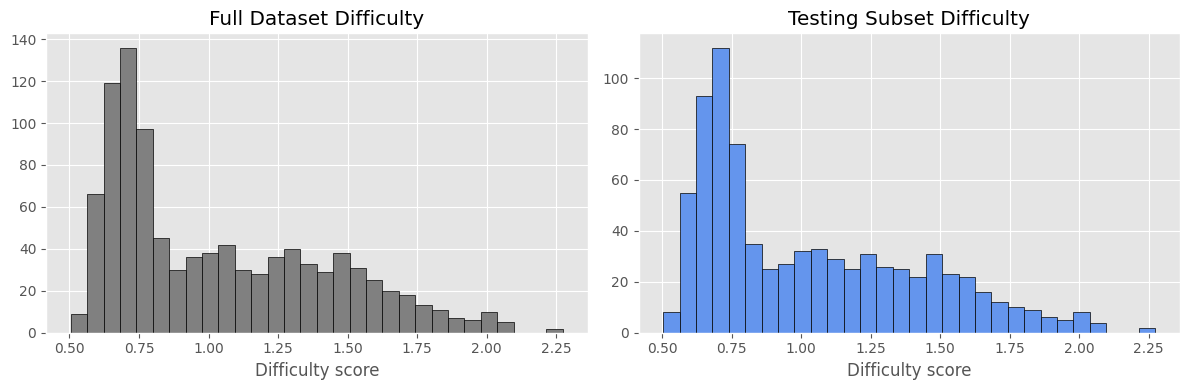

In [14]:
# Visual check: full dataset vs testing subset difficulty
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df_instances['difficulty_score'], bins=30, color='gray', edgecolor='black')
ax[0].set_title('Full Dataset Difficulty')
ax[0].set_xlabel('Difficulty score')

ax[1].hist(df_test['difficulty_score'], bins=30, color='cornflowerblue', edgecolor='black')
ax[1].set_title('Testing Subset Difficulty')
ax[1].set_xlabel('Difficulty score')

plt.tight_layout()
plt.show()

In [15]:
# 4) Load balancing algorithms
def makespan_from_assignment(tasks, assignment, m=N_SERVERS):
    loads = np.bincount(assignment, weights=tasks, minlength=m)
    return int(loads.max()), loads

def greedy_lpt(tasks, m=N_SERVERS):
    order = np.argsort(tasks)[::-1]
    loads = np.zeros(m, dtype=int)
    assignment = np.zeros(len(tasks), dtype=int)

    for i in order:
        s = int(np.argmin(loads))
        loads[s] += int(tasks[i])
        assignment[i] = s

    return int(loads.max()), assignment

def local_search(tasks, m=N_SERVERS, max_iters=250):
    best_ms, assignment = greedy_lpt(tasks, m)
    assignment = assignment.copy()

    for _ in range(max_iters):
        improved = False
        current_best_ms = best_ms
        best_candidate = None

        # Single-task moves
        for i in range(len(tasks)):
            src = assignment[i]
            for dst in range(m):
                if dst == src:
                    continue
                cand = assignment.copy()
                cand[i] = dst
                ms, _ = makespan_from_assignment(tasks, cand, m)
                if ms < current_best_ms:
                    current_best_ms = ms
                    best_candidate = cand
                    improved = True

        # Pair swaps
        for i in range(len(tasks)):
            for j in range(i + 1, len(tasks)):
                if assignment[i] == assignment[j]:
                    continue
                cand = assignment.copy()
                cand[i], cand[j] = cand[j], cand[i]
                ms, _ = makespan_from_assignment(tasks, cand, m)
                if ms < current_best_ms:
                    current_best_ms = ms
                    best_candidate = cand
                    improved = True

        if improved and best_candidate is not None:
            assignment = best_candidate
            best_ms = current_best_ms
        else:
            break

    return int(best_ms), assignment

def genetic_algorithm(tasks, m=N_SERVERS, pop_size=32, generations=50, mutation_rate=0.08, elite=2, seed=0):
    local_rng = np.random.default_rng(seed)
    n = len(tasks)

    def fitness(assign):
        return makespan_from_assignment(tasks, assign, m)[0]

    def random_individual():
        return local_rng.integers(0, m, size=n)

    _, greedy_seed = greedy_lpt(tasks, m)
    population = [greedy_seed.copy()] + [random_individual() for _ in range(pop_size - 1)]

    def tournament_select(k=3):
        picks = local_rng.choice(len(population), size=k, replace=False)
        return min((population[i] for i in picks), key=fitness)

    best = min(population, key=fitness).copy()
    best_fit = fitness(best)

    for _ in range(generations):
        scored = sorted(population, key=fitness)
        next_pop = [ind.copy() for ind in scored[:elite]]

        while len(next_pop) < pop_size:
            p1 = tournament_select()
            p2 = tournament_select()

            cut = local_rng.integers(1, n)
            child = np.concatenate([p1[:cut], p2[cut:]]).copy()

            mut_mask = local_rng.random(n) < mutation_rate
            if mut_mask.any():
                child[mut_mask] = local_rng.integers(0, m, size=mut_mask.sum())

            next_pop.append(child)

        population = next_pop
        candidate = min(population, key=fitness)
        candidate_fit = fitness(candidate)
        if candidate_fit < best_fit:
            best = candidate.copy()
            best_fit = candidate_fit

    return int(best_fit), best

In [16]:
# Exact solver (branch and bound) to compute optimal makespan on test subset
# This gives a reference for precision and error rate.
def exact_optimal_makespan(tasks, m=N_SERVERS):
    jobs = np.sort(tasks)[::-1]
    loads = [0] * m

    upper_bound, _ = greedy_lpt(tasks, m)
    best = upper_bound
    total = int(np.sum(jobs))

    def dfs(idx, assigned_sum):
        nonlocal best

        if idx == len(jobs):
            best = min(best, max(loads))
            return

        current_max = max(loads)
        if current_max >= best:
            return

        remaining = total - assigned_sum
        lower_bound = max(current_max, (sum(loads) + remaining + m - 1) // m)
        if lower_bound >= best:
            return

        job = int(jobs[idx])
        seen_loads = set()
        for s in range(m):
            if loads[s] in seen_loads:
                continue
            seen_loads.add(loads[s])

            loads[s] += job
            if loads[s] < best:
                dfs(idx + 1, assigned_sum + job)
            loads[s] -= job

            if loads[s] == 0:
                break

    dfs(0, 0)
    return int(best)

In [17]:
# 5) Benchmark algorithms on the testing subset
records = []

for local_id, sample_idx in enumerate(test_indices):
    tasks = dataset[sample_idx]
    optimal = exact_optimal_makespan(tasks, N_SERVERS)

    # Greedy
    t0 = time.perf_counter()
    pred_greedy, _ = greedy_lpt(tasks, N_SERVERS)
    dt_greedy = (time.perf_counter() - t0) * 1000
    records.append({
        'sample_id': int(sample_idx),
        'algorithm': 'Greedy (LPT)',
        'optimal': int(optimal),
        'predicted': int(pred_greedy),
        'runtime_ms': dt_greedy
    })

    # Local Search
    t0 = time.perf_counter()
    pred_local, _ = local_search(tasks, N_SERVERS)
    dt_local = (time.perf_counter() - t0) * 1000
    records.append({
        'sample_id': int(sample_idx),
        'algorithm': 'Local Search',
        'optimal': int(optimal),
        'predicted': int(pred_local),
        'runtime_ms': dt_local
    })

    # Genetic
    t0 = time.perf_counter()
    pred_genetic, _ = genetic_algorithm(tasks, N_SERVERS, seed=SEED + local_id)
    dt_genetic = (time.perf_counter() - t0) * 1000
    records.append({
        'sample_id': int(sample_idx),
        'algorithm': 'Genetic',
        'optimal': int(optimal),
        'predicted': int(pred_genetic),
        'runtime_ms': dt_genetic
    })

results = pd.DataFrame(records)
results['abs_error'] = results['predicted'] - results['optimal']
results['rel_error'] = results['abs_error'] / results['optimal']
results['is_exact'] = (results['predicted'] == results['optimal']).astype(int)

summary = results.groupby('algorithm', as_index=False).agg(
    avg_runtime_ms=('runtime_ms', 'mean'),
    median_runtime_ms=('runtime_ms', 'median'),
    precision=('is_exact', 'mean'),
    error_rate=('rel_error', 'mean'),
    worst_rel_error=('rel_error', 'max')
)
summary['precision_pct'] = 100 * summary['precision']
summary['error_rate_pct'] = 100 * summary['error_rate']
summary['worst_rel_error_pct'] = 100 * summary['worst_rel_error']

summary.round(3)

,algorithm,avg_runtime_ms,median_runtime_ms,precision,error_rate,worst_rel_error,precision_pct,error_rate_pct,worst_rel_error_pct
0,Genetic,36.669,35.704,0.316,0.007,0.041,31.625,0.711,4.065
1,Greedy (LPT),0.015,0.014,0.094,0.021,0.097,9.375,2.097,9.677
2,Local Search,0.243,0.228,0.456,0.005,0.048,45.625,0.531,4.795


/var/folders/jd/g2s72rjx5wzbcgtr1ftv5pxw0000gn/T/ipykernel_74890/325900302.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(box_data, labels=algo_order, showmeans=True)


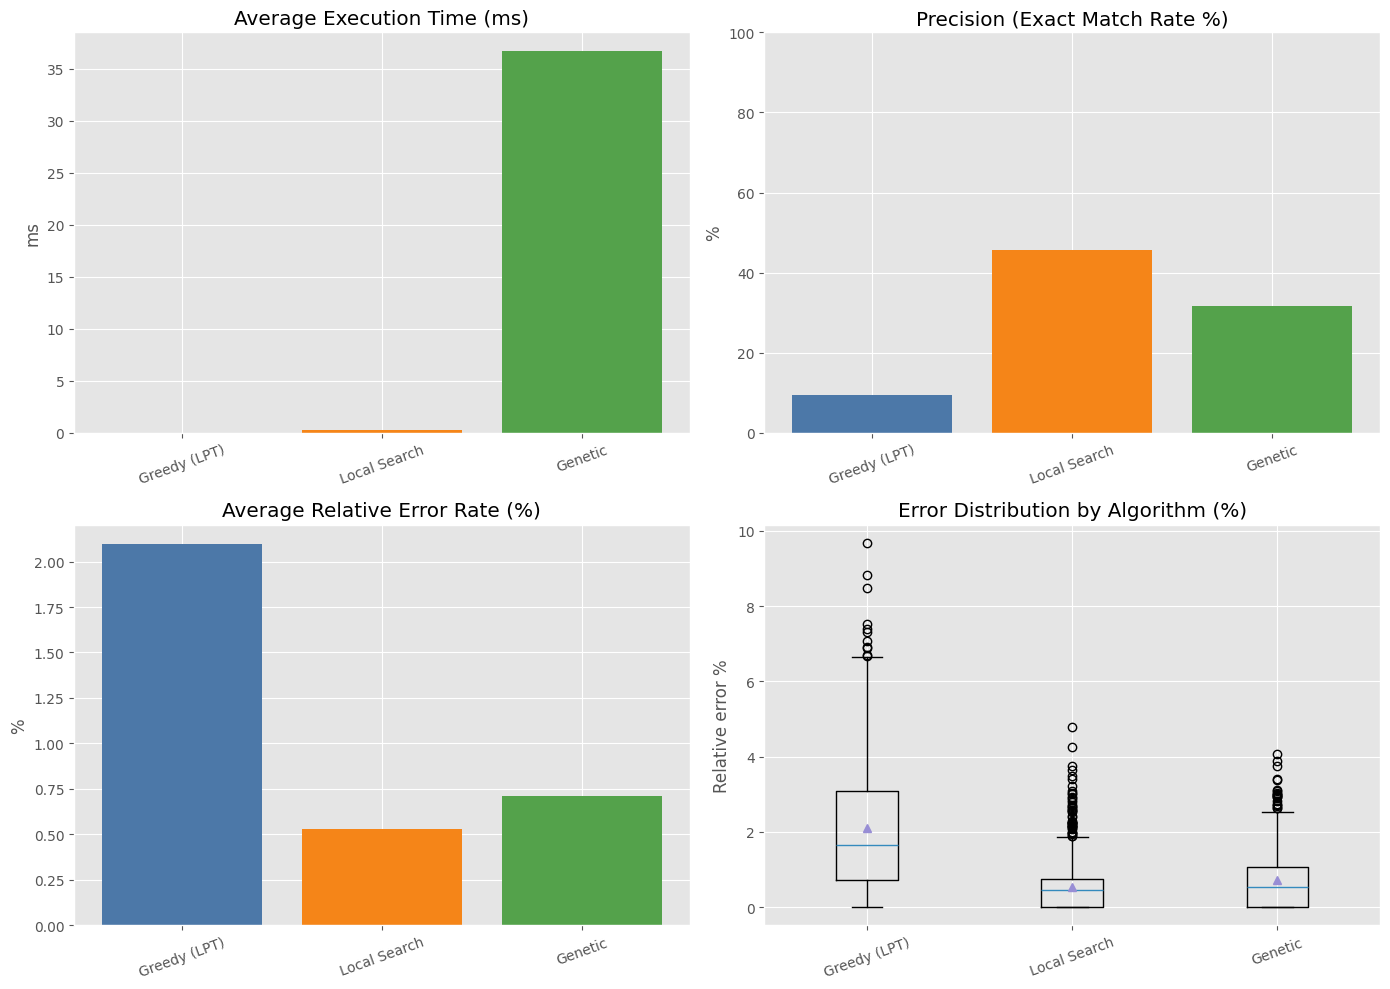

In [18]:
# 6) Charts for algorithm comparison
algo_order = summary.sort_values('avg_runtime_ms')['algorithm'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

runtime_data = summary.set_index('algorithm').loc[algo_order, 'avg_runtime_ms']
axes[0, 0].bar(runtime_data.index, runtime_data.values, color=['#4C78A8', '#F58518', '#54A24B'])
axes[0, 0].set_title('Average Execution Time (ms)')
axes[0, 0].set_ylabel('ms')
axes[0, 0].tick_params(axis='x', rotation=20)

precision_data = summary.set_index('algorithm').loc[algo_order, 'precision_pct']
axes[0, 1].bar(precision_data.index, precision_data.values, color=['#4C78A8', '#F58518', '#54A24B'])
axes[0, 1].set_title('Precision (Exact Match Rate %)')
axes[0, 1].set_ylabel('%')
axes[0, 1].set_ylim(0, 100)
axes[0, 1].tick_params(axis='x', rotation=20)

error_data = summary.set_index('algorithm').loc[algo_order, 'error_rate_pct']
axes[1, 0].bar(error_data.index, error_data.values, color=['#4C78A8', '#F58518', '#54A24B'])
axes[1, 0].set_title('Average Relative Error Rate (%)')
axes[1, 0].set_ylabel('%')
axes[1, 0].tick_params(axis='x', rotation=20)

box_data = [100 * results.loc[results['algorithm'] == a, 'rel_error'].values for a in algo_order]
axes[1, 1].boxplot(box_data, labels=algo_order, showmeans=True)
axes[1, 1].set_title('Error Distribution by Algorithm (%)')
axes[1, 1].set_ylabel('Relative error %')
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [19]:
# 7) Interpretation + final conclusion
fastest = summary.loc[summary['avg_runtime_ms'].idxmin(), 'algorithm']
best_precision = summary.loc[summary['precision'].idxmax(), 'algorithm']
lowest_error = summary.loc[summary['error_rate'].idxmin(), 'algorithm']

print('Interpretation:')
for _, row in summary.sort_values('algorithm').iterrows():
    print(
        f"- {row['algorithm']}: avg runtime={row['avg_runtime_ms']:.2f} ms, "
        f"precision={row['precision_pct']:.2f}%, error rate={row['error_rate_pct']:.3f}%"
    )

print('\nFinal conclusion:')
print(f'- Fastest algorithm: {fastest}')
print(f'- Most precise algorithm: {best_precision}')
print(f'- Lowest error rate: {lowest_error}')
print('- In general: Greedy is usually fastest, while Local Search and Genetic often trade more time for better quality.')
print('- Use Greedy for real-time decisions and use Local Search/Genetic when quality is more important than latency.')

Interpretation:
- Genetic: avg runtime=36.67 ms, precision=31.62%, error rate=0.711%
- Greedy (LPT): avg runtime=0.02 ms, precision=9.38%, error rate=2.097%
- Local Search: avg runtime=0.24 ms, precision=45.62%, error rate=0.531%

Final conclusion:
- Fastest algorithm: Greedy (LPT)
- Most precise algorithm: Local Search
- Lowest error rate: Local Search
- In general: Greedy is usually fastest, while Local Search and Genetic often trade more time for better quality.
- Use Greedy for real-time decisions and use Local Search/Genetic when quality is more important than latency.
